# Final enhanced-algorithm evaluation

This notebook reports the one-time 415-image test run using the enhanced configurations selected by validation F1-score. It does not tune parameters or execute the algorithms itself. The authoritative settings are in `configs/frozen_parameters.yaml`; the guarded runner is `scripts/evaluation/run_final_evaluation.py`.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name in ('validation', 'final_evaluation') else (Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
RESULTS_PATH = PROJECT_ROOT / 'outputs/metrics/final_test_results.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs/metrics/final_test_summary.json'
assert RESULTS_PATH.is_file() and SUMMARY_PATH.is_file(), (
    'Run scripts/evaluation/run_final_evaluation.py --confirm-frozen-test first.'
)
results = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
assert len(results) == 1660
assert set(results['split']) == {'test'}
assert set(results['status']) == {'success'}
assert set(results['algorithm']) == {'otsu', 'template_matching', 'canny', 'orb'}
assert set(results['algorithm_version']) == {'enhanced-frozen-v1'}
assert summary['split'] == 'test' and summary['test_images'] == 415
assert summary['orb_calibrate'] is False
len(results), results['split'].unique().tolist(), results['algorithm'].value_counts().to_dict()

(1660,
 ['test'],
 {'otsu': 415, 'canny': 415, 'template_matching': 415, 'orb': 415})

## Overall comparison

In [2]:
overall = pd.DataFrame(summary['overall']).T
display(overall[[
    'precision', 'recall', 'f1_score', 'mean_matched_iou',
    'false_positives_per_image', 'mean_runtime_ms', 'frames_per_second'
]].sort_values('f1_score', ascending=False))

,precision,recall,f1_score,mean_matched_iou,false_positives_per_image,mean_runtime_ms,frames_per_second
otsu,0.844042,0.815003,0.829268,0.601500,0.643373,39.512980,25.308139
template_matching,0.380970,0.571348,0.457130,0.521293,3.966265,1382.665214,0.723241
canny,0.038740,0.096447,0.055277,0.182560,10.224096,172.810472,5.786686
orb,0.003312,0.126904,0.006455,0.208511,163.166265,614.852253,1.626407


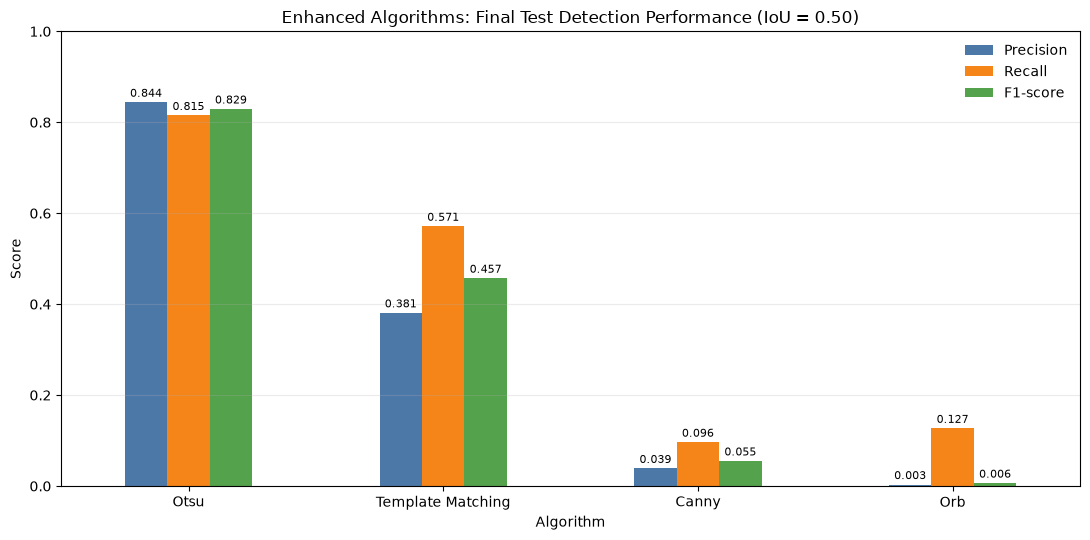

In [3]:
plot_order = overall.sort_values('f1_score', ascending=False).index
labels = [name.replace('_', ' ').title() for name in plot_order]
metric_values = overall.loc[plot_order, ['precision', 'recall', 'f1_score']]

fig, ax = plt.subplots(figsize=(11, 5.5))
metric_values.plot.bar(ax=ax, rot=0, color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('Enhanced Algorithms: Final Test Detection Performance (IoU = 0.50)')
ax.set_ylabel('Score')
ax.set_xlabel('Algorithm')
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.25)
ax.legend(['Precision', 'Recall', 'F1-score'], frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


## Performance by defect class

,Canny,Orb,Otsu,Template Matching
missing_hole,0.071775,0.014135,0.924837,0.440145
mouse_bite,0.038314,0.003615,0.904014,0.468421
open_circuit,0.101554,0.010446,0.830054,0.528044
short_circuit,0.032223,0.009577,0.549815,0.151786
spur,0.044164,0.000510,0.864111,0.434540
spurious_copper,0.045850,0.001002,0.876800,0.698895


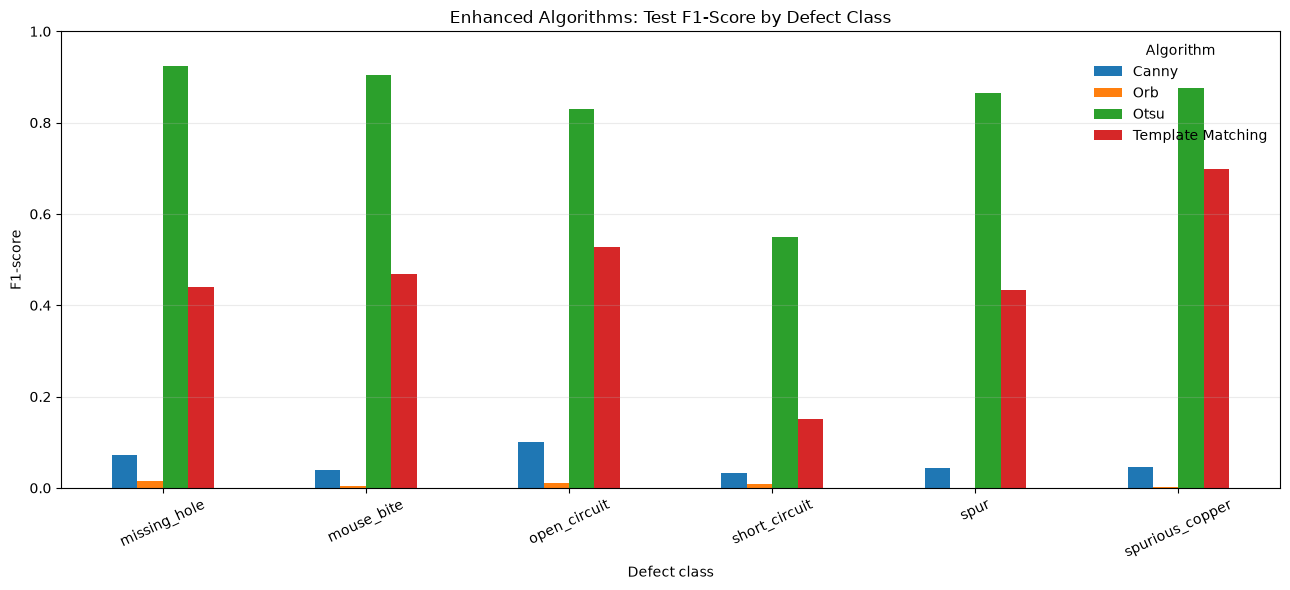

In [4]:
class_f1 = pd.DataFrame({
    algorithm: {name: values['f1_score'] for name, values in classes.items()}
    for algorithm, classes in summary['by_class'].items()
}).sort_index()
class_f1 = class_f1.rename(columns=lambda name: name.replace('_', ' ').title())
display(class_f1)
ax = class_f1.plot.bar(figsize=(13, 6), rot=25)
ax.set_title('Enhanced Algorithms: Test F1-Score by Defect Class')
ax.set_ylabel('F1-score')
ax.set_xlabel('Defect class')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Algorithm', frameon=False)
plt.tight_layout()
plt.show()


### Per-class findings

Enhanced Otsu achieves the highest F1-score for every defect category. Its strongest categories are missing hole and mouse bite, while short circuit remains its most challenging category. Enhanced Template Matching ranks second overall. Enhanced Canny and enhanced ORB remain substantially weaker for direct bounding-box localisation. These are final observations and were not used for parameter tuning.


## Representative enhanced Otsu test examples

The examples below are selected from the completed test results only for explanation. Red boxes are XML ground truth and cyan boxes are enhanced Otsu predictions. The displayed TP/FP/FN counts use the same one-to-one IoU 0.50 rule as the full comparison.


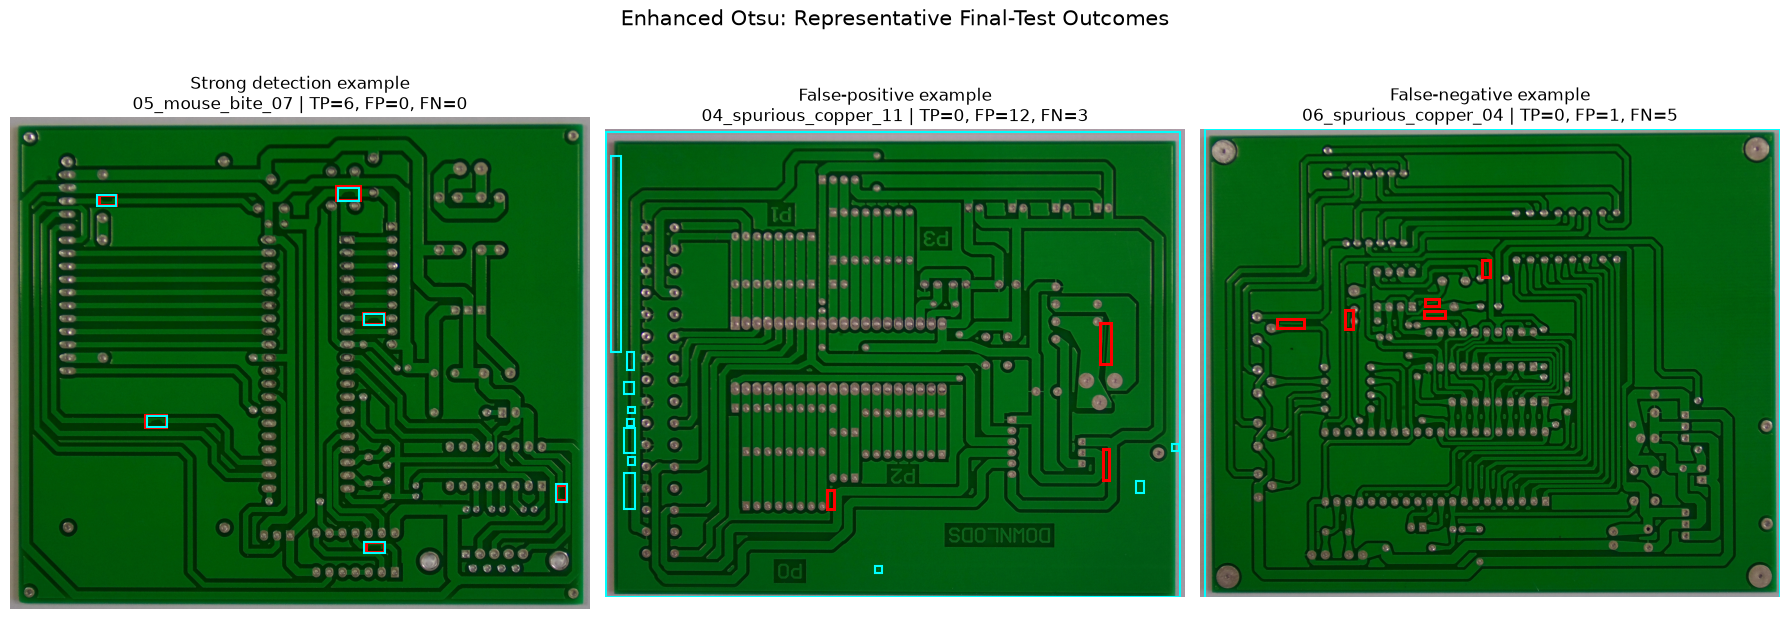

In [5]:
import sys
import cv2
from matplotlib.patches import Rectangle
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from algorithms.evaluation import parse_voc_boxes

manifest = pd.read_csv(PROJECT_ROOT / 'data/dataset_split.csv').set_index('image_id')
otsu_results = results[(results.algorithm == 'otsu') & (results.status == 'success')].copy()
example_rows = [
    ('Strong detection example', otsu_results.sort_values(['true_positives', 'f1_score'], ascending=False).iloc[0]),
    ('False-positive example', otsu_results.sort_values(['false_positives', 'true_positives'], ascending=False).iloc[0]),
    ('False-negative example', otsu_results.sort_values(['false_negatives', 'true_positives'], ascending=False).iloc[0]),
]

def project_path(path_text):
    path = Path(path_text)
    return path if path.is_absolute() else PROJECT_ROOT / path

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for axis, (label, record) in zip(axes, example_rows):
    source = manifest.loc[record.image_id]
    image = cv2.cvtColor(cv2.imread(str(project_path(source.image_path))), cv2.COLOR_BGR2RGB)
    truth = parse_voc_boxes(project_path(source.annotation_path))
    predicted = np.load(project_path(record.predicted_boxes_path))
    axis.imshow(image)
    for box in truth:
        axis.add_patch(Rectangle(
            (box['xmin'], box['ymin']), box['xmax'] - box['xmin'], box['ymax'] - box['ymin'],
            fill=False, edgecolor='red', linewidth=2.2,
        ))
    for xmin, ymin, xmax, ymax in predicted:
        axis.add_patch(Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            fill=False, edgecolor='cyan', linewidth=1.5,
        ))
    axis.set_title(
        f"{label}\n{record.image_id} | TP={int(record.true_positives)}, "
        f"FP={int(record.false_positives)}, FN={int(record.false_negatives)}"
    )
    axis.axis('off')
fig.suptitle('Enhanced Otsu: Representative Final-Test Outcomes', fontsize=15)
plt.tight_layout()
plt.show()


### What the examples show

- The strong-detection example shows enhanced Otsu consolidating difference pixels into boxes that overlap the annotated defects.
- The false-positive example shows where a predicted difference region does not achieve a valid one-to-one match with the ground truth.
- The false-negative example shows where annotated defects remain unmatched at IoU 0.50.

These examples were selected after the final evaluation for explanation only and were not used to change the frozen configuration.


## Interpretation rule

These test results are final comparison measurements. Thresholds, preprocessing, box generation, and matching rules were frozen using validation F1-score before this test run and were not changed after inspecting the test results.
